In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Chargement du dataset
# Assure-toi que le fichier est dans le même dossier que ton notebook
df = pd.read_csv('chatbot_meteo_dataset.csv')

# Affichage des 5 premières lignes (Livrable demandé)
print("Aperçu des données :")
df.head()

# Résumé des colonnes (Livrable demandé)
print("\nInformations sur les colonnes :")
df.info()

Aperçu des données :

Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118000 entries, 0 to 117999
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   texte      118000 non-null  object
 1   intention  118000 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB


# Etape 2
 Nettoyage des donnees

In [9]:
# 1. Suppression des lignes vides s'il y en a
df = df.dropna()
# On retire les doublons
df = df.drop_duplicates()

# 2. Fonction de nettoyage (Livrable : retrait de la ponctuation et mise en minuscule)
def clean_text(text):
    text = text.lower() # Tout en minuscules
    text = re.sub(r'[^\w\s]', '', text) # Retire la ponctuation (ex: ?, !, ")
    return text

df['texte_nettoye'] = df['texte'].apply(clean_text)

print("Données après nettoyage :")
display(df[['texte', 'texte_nettoye', 'intention']].head())

Données après nettoyage :


,texte,texte_nettoye,intention
0,Météo du jour à Granby ?,météo du jour à granby,meteo_actuelle
1,Combien de degrés Celsius à Nice ?,combien de degrés celsius à nice,temperature
2,Est-ce qu'il y a du verglas à Lyon ?,estce quil y a du verglas à lyon,neige
3,Qu'est-ce que je devrais porter aujourd'hui ?,questce que je devrais porter aujourdhui,conseil_vetement
4,Avertissement de gel à Rouyn-Noranda ?,avertissement de gel à rouynnoranda,alerte_meteo


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14888\1561441998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats.index, y=stats.values, palette='viridis')


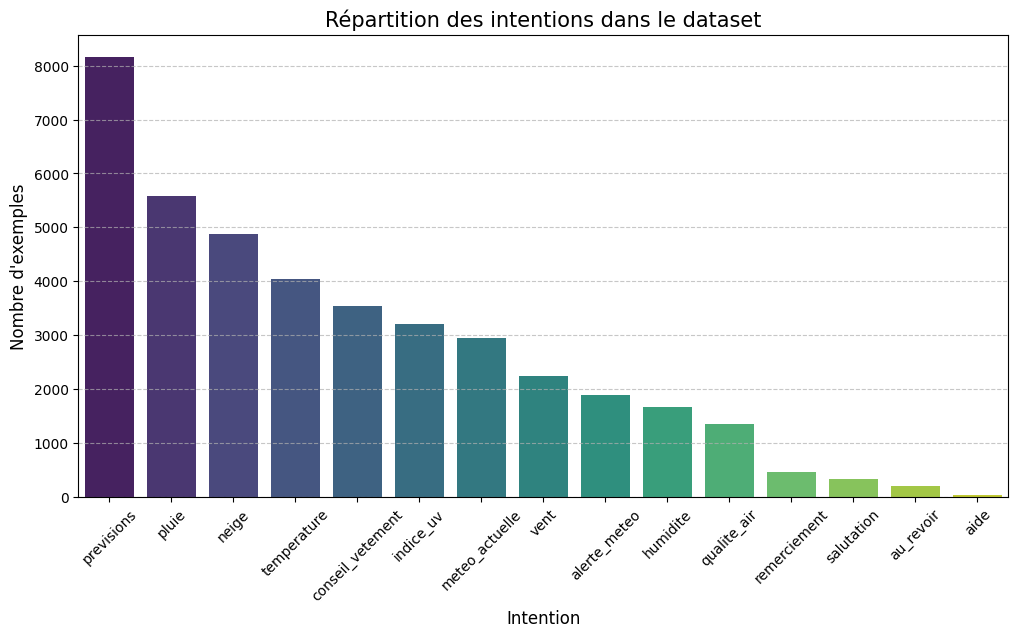

Nombre total d'exemples : 40610

Nombre d'exemples par catégorie :
intention
previsions          8153
pluie               5588
neige               4870
temperature         4043
conseil_vetement    3551
indice_uv           3205
meteo_actuelle      2954
vent                2244
alerte_meteo        1892
humidite            1679
qualite_air         1360
remerciement         474
salutation           342
au_revoir            210
aide                  45
Name: count, dtype: int64


In [10]:
# Calcul des statistiques par intention
stats = df['intention'].value_counts()

# Affichage du graphique (Livrable : graphique en barres)
plt.figure(figsize=(12, 6))
sns.barplot(x=stats.index, y=stats.values, palette='viridis')

plt.title('Répartition des intentions dans le dataset', fontsize=15)
plt.xlabel('Intention', fontsize=12)
plt.ylabel('Nombre d\'exemples', fontsize=12)
plt.xticks(rotation=45) # Rotation pour mieux lire les noms
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

print("Nombre total d'exemples :", len(df))
print("\nNombre d'exemples par catégorie :")
print(stats)

# Etape 3
 Vectorisation

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Division des données : 80% pour l'entraînement, 20% pour le test
X = df['texte_nettoye']
y = df['intention']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Transformation du texte en nombres (Vectorisation TF-IDF)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Nombre de phrases d'entraînement : {X_train.shape[0]}")
print(f"Nombre de phrases de test : {X_test.shape[0]}")

Nombre de phrases d'entraînement : 32488
Nombre de phrases de test : 8122


Entrainement du modele foret aleatoire

In [12]:
from sklearn.ensemble import RandomForestClassifier

# 3. Création et entraînement du modèle Random Forest
# On peut ajuster n_estimators pour la performance
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_tfidf, y_train)

# 4. Prédiction
y_pred = model_rf.predict(X_test_tfidf)

print("Modèle Forêt Aléatoire entraîné avec succès !")

Modèle Forêt Aléatoire entraîné avec succès !


Sauvegarde du modele et du vectorizer

Précision globale (Accuracy) : 1.00

Rapport détaillé :
                  precision    recall  f1-score   support

            aide       1.00      0.58      0.74        12
    alerte_meteo       1.00      1.00      1.00       395
       au_revoir       0.95      1.00      0.97        39
conseil_vetement       1.00      1.00      1.00       687
        humidite       1.00      1.00      1.00       339
       indice_uv       1.00      1.00      1.00       649
  meteo_actuelle       1.00      1.00      1.00       588
           neige       1.00      1.00      1.00       950
           pluie       1.00      1.00      1.00      1115
      previsions       1.00      1.00      1.00      1681
     qualite_air       1.00      1.00      1.00       276
    remerciement       1.00      0.98      0.99        87
      salutation       0.97      1.00      0.99        71
     temperature       1.00      1.00      1.00       783
            vent       1.00      1.00      1.00       450

        accura

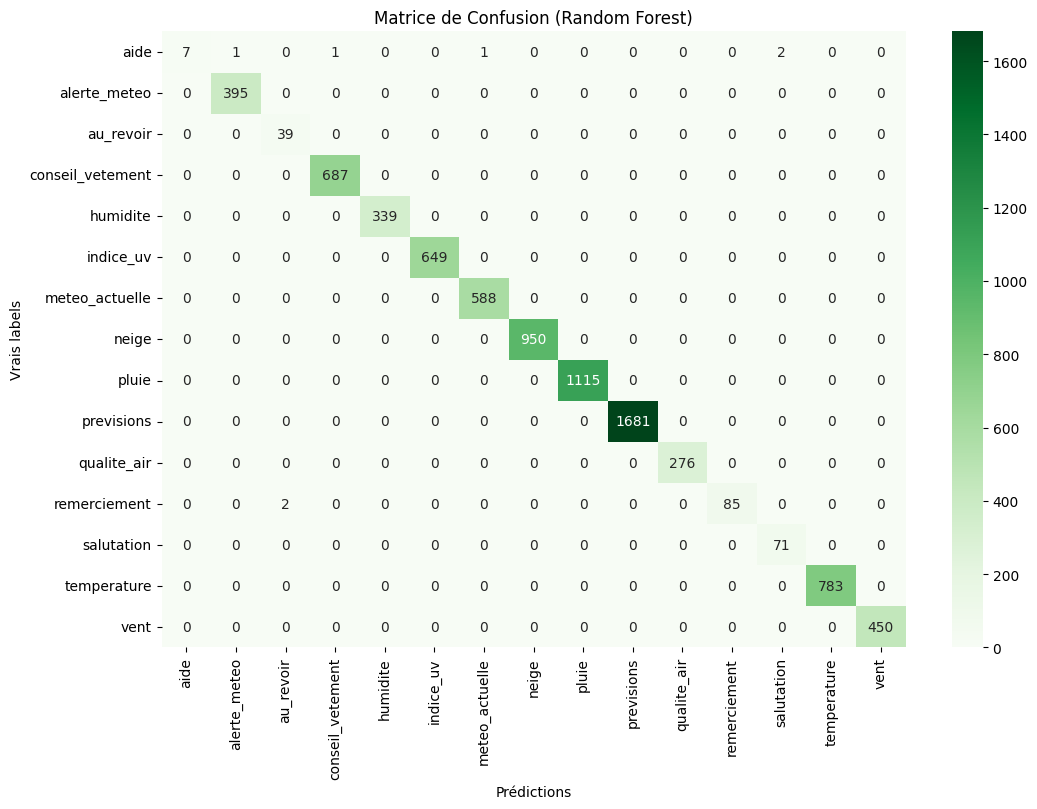

Fichiers sauvegardés : 'model_meteo.pkl' et 'vectorizer.pkl'


In [13]:
# 5. Affichage des résultats
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred))

# 6. Matrice de confusion
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model_rf.classes_, yticklabels=model_rf.classes_, cmap='Greens')
plt.xlabel('Prédictions')
plt.ylabel('Vrais labels')
plt.title('Matrice de Confusion (Random Forest)')
plt.show()

# 7. Sauvegarde
joblib.dump(model_rf, 'model_meteo.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')
print("Fichiers sauvegardés : 'model_meteo.pkl' et 'vectorizer.pkl'")

Test du modele

In [14]:
def predict_intent(phrase):
    # Charger le modèle et le vectoriseur
    m = joblib.load('model_meteo.pkl')
    v = joblib.load('vectorizer.pkl')
    # Transformer la phrase et prédire
    phrase_vec = v.transform([phrase.lower()])
    prediction = m.predict(phrase_vec)
    return prediction[0]

# Test
test_phrase = "Faut-il un parapluie à Montréal ?"
print(f"Phrase : {test_phrase} -> Intention détectée : {predict_intent(test_phrase)}")

Phrase : Faut-il un parapluie à Montréal ? -> Intention détectée : conseil_vetement
